# SEMINAR – SUPERVISED LEARNING: REGRESSION
## Electronics Products Pricing – Bối cảnh bán lẻ điện máy
**Dataset:** `electronics_products_pricing.csv`

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

pd.set_option('display.max_columns', None)

## I. GIỚI THIỆU
### 1.1. Bối cảnh kinh doanh

Trong lĩnh vực bán lẻ điện máy, giá sản phẩm có thể liên quan đến nhiều yếu tố như thương hiệu, danh mục, trọng lượng, tình trạng sản phẩm và chương trình khuyến mãi.

### 1.2. Bài toán hồi quy

- **Biến mục tiêu (target):** `price`
- **Mục tiêu:** dự đoán giá sản phẩm.
- **Mô hình:** Linear Regression, Decision Tree Regression và Random Forest Regression.

In [2]:
#Đọc dữ liệu

df = pd.read_csv("electronics_products_pricing.csv")

print("Kích thước dữ liệu:", df.shape)
df.head()

Kích thước dữ liệu: (5436, 25)


,id,prices.availability,prices.condition,prices.currency,prices.dateSeen,prices.isSale,prices.merchant,prices.shipping,prices.sourceURLs,asins,brand,categories,dateAdded,dateUpdated,ean,imageURLs,keys,manufacturer,manufacturerNumber,name,primaryCategories,sourceURLs,upc,weight,price
0,AVphrugr1cnluZ0-FOeH,Yes,New,USD,"2017-05-10T20:00:00Z,2017-05-09T15:00:00Z",False,Bestbuy.com,NaN,http://www.bestbuy.com/site/products/7100293.p...,B00I9HD8PK,Grace Digital,"Electronics,Home Audio & Theater,Home Audio,Al...",2015-11-01T00:57:52Z,2018-02-13T19:46:08Z,NaN,https://i5.walmartimages.com/asr/dd5f42c4-076c...,"819127010485,ecoxgearecostonebluetoothspeaker/...",Ecoxgear,GDI-EGST701,EcoXGear Ecostone Bluetooth Speaker,Electronics,http://www.walmart.com/ip/EcoXGear-Ecostone-Bl...,8.19E+11,3 pounds,92.99
1,AVrI6FDbv8e3D1O-lm4R,Yes,New,USD,"2017-10-10T02:00:00Z,2017-08-12T03:00:00Z,2017...",False,Bestbuy.com,NaN,https://www.bestbuy.com/site/lenovo-100s-14ibr...,B06ZY63J8H,Lenovo,"Electronics,Computers,Laptops,Laptops By Brand...",2017-03-13T18:22:32Z,2018-01-30T06:06:16Z,NaN,https://i5.walmartimages.com/asr/fcc50cce-a3c1...,"190793918948,lenovo100s14ibr14laptopintelceler...",NaN,100s-14ibr,Lenovo - 100S-14IBR 14 Laptop - Intel Celeron ...,Electronics,https://www.walmart.com/ip/Lenovo-100S-14IBR-1...,1.91E+11,4.3 pounds,229.99
2,AVpiLlubilAPnD_xBoTa,Yes,New,USD,"2017-10-10T19:00:00Z,2017-09-12T14:00:00Z,2017...",False,Bestbuy.com,NaN,https://www.bestbuy.com/site/house-of-marley-s...,B00G3P9UMU,House of Marley,"Headphones,Consumer Electronics,Portable Audio...",2014-10-28T18:47:20Z,2018-05-16T20:23:54Z,8.47E+11,https://i5.walmartimages.com/asr/c124aa15-b9e3...,"0846885007037,houseofmarleysmilejamaicainearea...",House Of Marley,EM-JE041-MI,House of Marley Smile Jamaica In-Ear Earbuds,Electronics,https://www.walmart.com/ip/House-of-Marley-Smi...,8.47E+11,0.6 ounces,16.99
3,AVpgQP5vLJeJML43LQbd,Yes,New,USD,"2017-09-08T05:00:00Z,2017-09-18T13:00:00Z,2017...",False,Bestbuy.com,NaN,https://www.bestbuy.com/site/products/6311012....,B00TTWZFFA,Sony,"Electronics,Home Audio & Theater,Home Audio,Al...",2015-11-06T00:24:21Z,2018-01-30T03:06:18Z,NaN,https://i5.walmartimages.com/asr/1be435f7-5f3a...,"sonyultraportablebluetoothspeaker/sosrsx11bk,s...",Sony,SRSX11/BLK,Sony Ultra-Portable Bluetooth Speaker,Electronics,https://www.walmart.com/ip/Sony-Ultra-Portable...,27242886599,1 pounds,69.99
4,AV1YDsmoGV-KLJ3adcbe,More on the Way,New,USD,2017-12-05T13:00:00Z,True,bhphotovideo.com,Free Expedited Shipping for most orders over $49,https://www.bhphotovideo.com/c/product/1105014...,B00MHPAF38,Sony,"Digital Cameras,Cameras & Photo,Used:Digital P...",2017-07-18T23:35:50Z,2018-07-26T15:58:38Z,NaN,http://i.ebayimg.com/thumbs/images/g/TBUAAOSwd...,sonyalphaa5100digitalcamerakitwith1650mmlenswh...,NaN,ILCE5100L/W,Alpha a5100 Mirrorless Digital Camera with 16-...,Electronics,https://reviews.bestbuy.com/3545/8429343/revie...,27242883246,9.98 oz 4.09 oz,846.00


## II. MÔ TẢ DỮ LIỆU

In [3]:
#Kiểm tra tổng quan dữ liệu

print("Số dòng:", len(df))
print("Số cột:", len(df.columns))

print("\nTên các cột:")
print(df.columns.tolist())

print("\nKiểu dữ liệu:")
print(df.dtypes)

Số dòng: 5436
Số cột: 25

Tên các cột:
['id', 'prices.availability', 'prices.condition', 'prices.currency', 'prices.dateSeen', 'prices.isSale', 'prices.merchant', 'prices.shipping', 'prices.sourceURLs', 'asins', 'brand', 'categories', 'dateAdded', 'dateUpdated', 'ean', 'imageURLs', 'keys', 'manufacturer', 'manufacturerNumber', 'name', 'primaryCategories', 'sourceURLs', 'upc', 'weight', 'price']

Kiểu dữ liệu:
id                         str
prices.availability        str
prices.condition           str
prices.currency            str
prices.dateSeen            str
prices.isSale             bool
prices.merchant            str
prices.shipping            str
prices.sourceURLs          str
asins                      str
brand                      str
categories                 str
dateAdded                  str
dateUpdated                str
ean                        str
imageURLs                  str
keys                       str
manufacturer               str
manufacturerNumber         st

In [4]:
#Kiểm tra dữ liệu thiếu và dữ liệu trùng

print("Số giá trị thiếu:")
print(df.isnull().sum())

print("\nSố dòng trùng:", df.duplicated().sum())

Số giá trị thiếu:
id                        0
prices.availability       0
prices.condition          0
prices.currency           0
prices.dateSeen           0
prices.isSale             0
prices.merchant           0
prices.shipping        2237
prices.sourceURLs         0
asins                     0
brand                     0
categories                0
dateAdded                 0
dateUpdated               0
ean                    4261
imageURLs                 0
keys                      0
manufacturer           2959
manufacturerNumber        0
name                      0
primaryCategories         0
sourceURLs                0
upc                       0
weight                    0
price                     0
dtype: int64

Số dòng trùng: 0


## III. PHÂN TÍCH KHÁM PHÁ DỮ LIỆU (EDA)
### 3.1. Thống kê mô tả

In [5]:
#Thống kê mô tả Price

print(df["price"].describe())

print("\nGiá nhỏ nhất:", df["price"].min())
print("Giá trung bình:", df["price"].mean())
print("Giá trung vị:", df["price"].median())
print("Giá lớn nhất:", df["price"].max())

count    5436.000000
mean      492.941161
std       769.246463
min         1.000000
25%        79.950000
50%       194.410000
75%       486.952500
max      6999.990000
Name: price, dtype: float64

Giá nhỏ nhất: 1.0
Giá trung bình: 492.9411607799852
Giá trung vị: 194.41
Giá lớn nhất: 6999.99


### 3.2. Phân bố giá

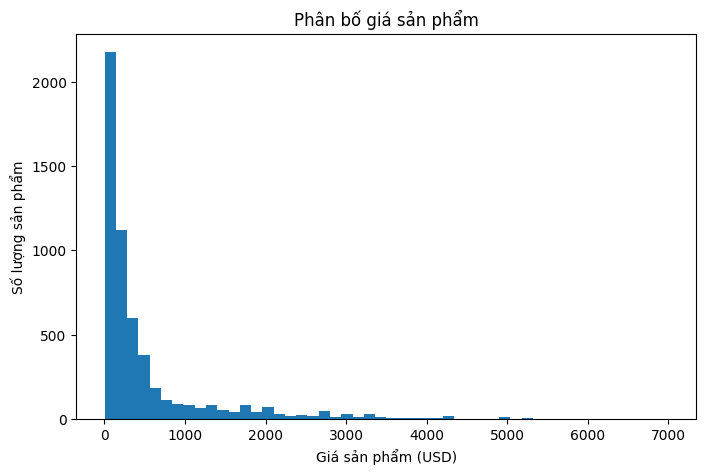

In [6]:
#Biểu đồ phân bố giá

plt.figure(figsize=(8, 5))
plt.hist(df["price"].dropna(), bins=50)

plt.xlabel("Giá sản phẩm (USD)")
plt.ylabel("Số lượng sản phẩm")
plt.title("Phân bố giá sản phẩm")

plt.show()

### 3.3. Giá theo thương hiệu

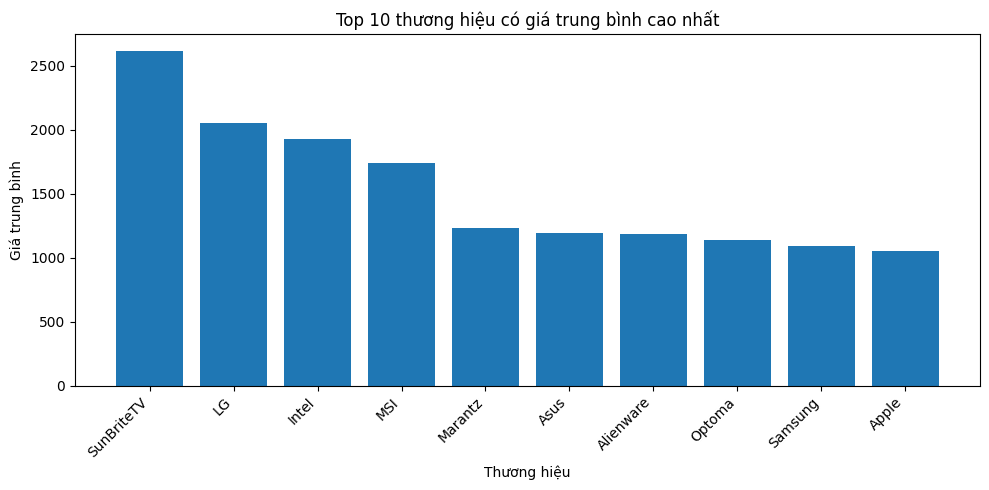

In [7]:
#Top 10 thương hiệu có giá trung bình cao nhất

avg_price = (
    df.groupby('brand')['price']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(10, 5))
plt.bar(avg_price.index.astype(str), avg_price.values)

plt.title('Top 10 thương hiệu có giá trung bình cao nhất')
plt.xlabel('Thương hiệu')
plt.ylabel('Giá trung bình')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 3.4. Giá theo nhóm danh mục

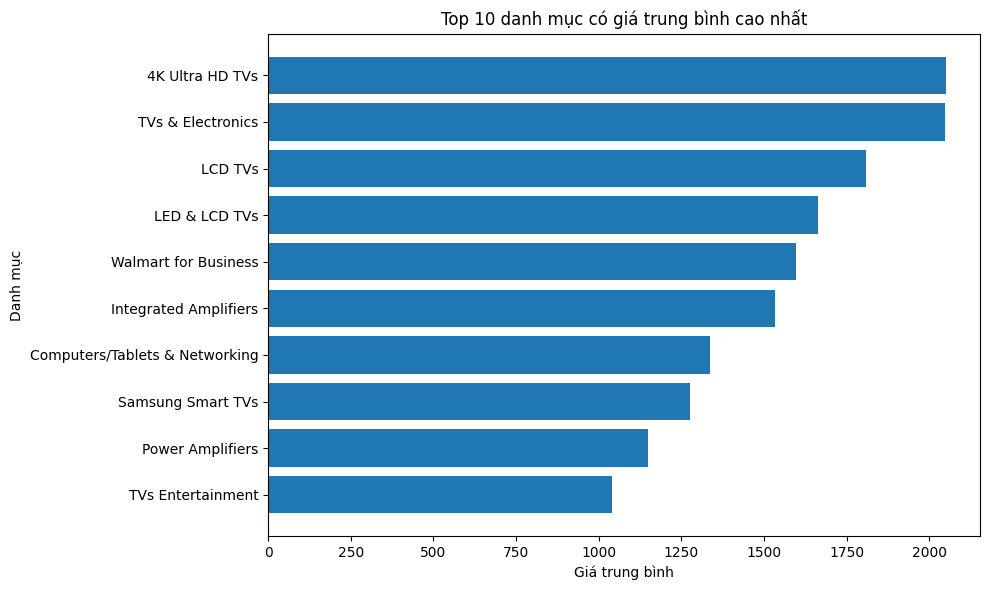

In [8]:
#Top 10 danh mục có giá trung bình cao nhất

df['category'] = (
    df['categories']
    .fillna('')
    .astype(str)
    .str.split(',')
    .str[0]
    .str.strip()
)

avg_category_price = (
    df.groupby('category')['price']
      .mean()
      .sort_values(ascending=False)
)

top_category_price = avg_category_price.head(10).sort_values()

plt.figure(figsize=(10, 6))
plt.barh(top_category_price.index.astype(str), top_category_price.values)

plt.title('Top 10 danh mục có giá trung bình cao nhất')
plt.xlabel('Giá trung bình')
plt.ylabel('Danh mục')
plt.tight_layout()
plt.show()

### 3.5. Tỷ lệ sản phẩm khuyến mãi và tình trạng sản phẩm

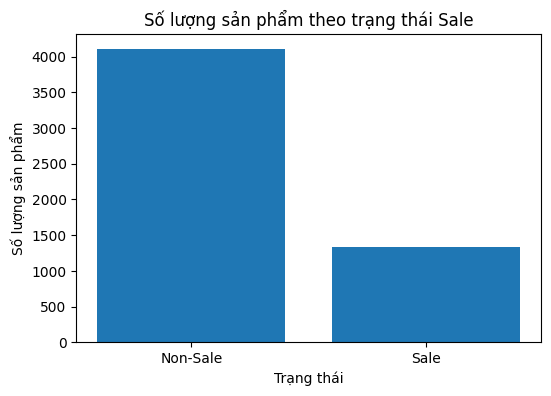

prices.isSale
Non-Sale    4109
Sale        1327
Name: count, dtype: int64


In [9]:
#Tỷ lệ sản phẩm Sale

sale_status = df['prices.isSale'].map({
    True: 'Sale',
    False: 'Non-Sale'
})

sale_count = sale_status.value_counts()

plt.figure(figsize=(6, 4))
plt.bar(sale_count.index, sale_count.values)

plt.title('Số lượng sản phẩm theo trạng thái Sale')
plt.xlabel('Trạng thái')
plt.ylabel('Số lượng sản phẩm')
plt.show()

print(sale_count)

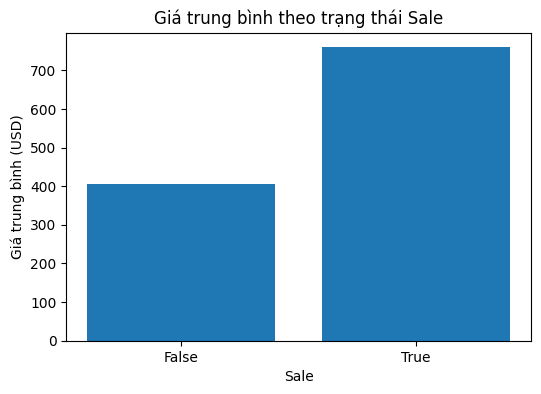

isSale_label
False    406.844057
True     759.537242
Name: price, dtype: float64


In [10]:
#So sánh giá trung bình Sale và Non-Sale

sale_price_summary = (
    df.assign(
        isSale_label=df['prices.isSale'].map({
            True: 'True',
            False: 'False'
        })
    )
    .groupby('isSale_label')['price']
    .mean()
    .reindex(['False', 'True'])
)

plt.figure(figsize=(6, 4))
plt.bar(sale_price_summary.index, sale_price_summary.values)

plt.title('Giá trung bình theo trạng thái Sale')
plt.xlabel('Sale')
plt.ylabel('Giá trung bình (USD)')
plt.show()

print(sale_price_summary)

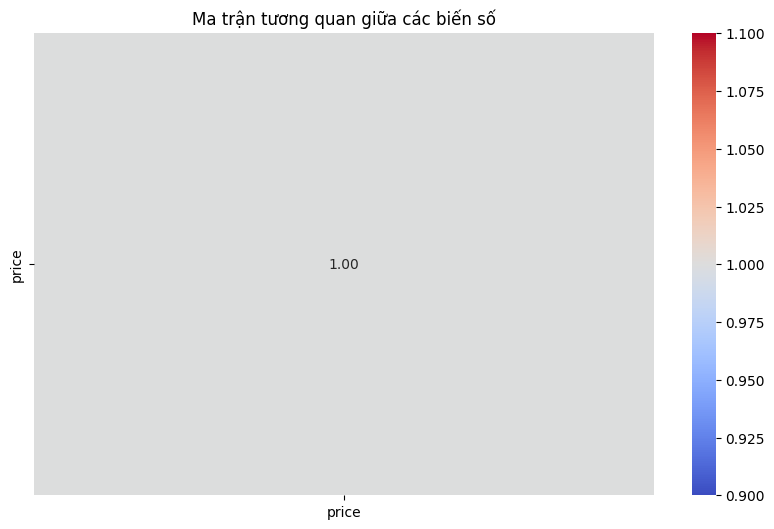

In [11]:
#Ma trận tương quan giữa các biến số

numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')

plt.title('Ma trận tương quan giữa các biến số')
plt.show()

## IV. TIỀN XỬ LÝ DỮ LIỆU
### 4.1. Loại bỏ thuộc tính không phù hợp

In [12]:
#Loại bỏ các trường định danh/URL không dùng trực tiếp

drop_cols = [
    'id', 'asins', 'ean', 'imageURLs', 'keys',
    'dateAdded', 'dateUpdated', 'prices.dateSeen',
    'sourceURLs', 'upc', 'prices.currency',
    'manufacturerNumber'
]

model_base = df.drop(columns=drop_cols, errors='ignore').copy()

print("Kích thước sau khi loại bỏ thuộc tính:", model_base.shape)

Kích thước sau khi loại bỏ thuộc tính: (5436, 14)


### 4.2. Xử lý dữ liệu thiếu

In [13]:
#Kiểm tra missing values của các biến quan trọng

selected_cols = [
    'prices.availability',
    'prices.condition',
    'prices.isSale',
    'prices.merchant',
    'prices.shipping',
    'brand',
    'category',
    'primaryCategories',
    'weight',
    'price'
]

print(df[selected_cols].isnull().sum())

prices.availability       0
prices.condition          0
prices.isSale             0
prices.merchant           0
prices.shipping        2237
brand                     0
category                  0
primaryCategories         0
weight                    0
price                     0
dtype: int64


### 4.3. Chuẩn hóa/biến đổi Weight

In [14]:
#Chuyển Weight về kilogram

def convert_weight_to_kg(value):
    if pd.isna(value):
        return np.nan

    value = str(value).lower().strip()

    match = re.search(
        r'([\d.]+)\s*(pounds?|lbs?|lb|ounces?|oz|kg)',
        value
    )

    if match is None:
        return np.nan

    number = float(match.group(1))
    unit = match.group(2)

    if unit == 'kg':
        return number
    elif unit in ['pound', 'pounds', 'lb', 'lbs']:
        return number * 0.453592
    elif unit in ['ounce', 'ounces', 'oz']:
        return number * 0.0283495

    return np.nan

df['weight_kg'] = df['weight'].apply(convert_weight_to_kg)

print(df[['weight', 'weight_kg']].head(10))

            weight  weight_kg
0         3 pounds   1.360776
1       4.3 pounds   1.950446
2       0.6 ounces   0.017010
3         1 pounds   0.453592
4  9.98 oz 4.09 oz   0.282928
5             15.6        NaN
6      54.5 pounds  24.720764
7      18.3 pounds   8.300734
8           3.2 Kg   3.200000
9  9.98 oz 4.09 oz   0.282928


### 4.4. Mã hóa biến phân loại

In [15]:
#Chuẩn bị dữ liệu mô hình cơ sở

baseline_df = df[['weight_kg', 'price']].dropna().copy()

X_baseline = baseline_df[['weight_kg']]
y_baseline = baseline_df['price']

print("Số dòng sau khi xử lý Weight:", len(baseline_df))
print("Số feature:", X_baseline.shape[1])

Số dòng sau khi xử lý Weight: 5370
Số feature: 1


### 4.5. Chia dữ liệu huấn luyện và kiểm tra

In [16]:
#Chia dữ liệu 80% Train và 20% Test

X_train, X_test, y_train, y_test = train_test_split(
    X_baseline,
    y_baseline,
    test_size=0.2,
    random_state=42
)

print("Số dòng tập huấn luyện:", len(X_train))
print("Số dòng tập kiểm tra:", len(X_test))
print("Tỷ lệ train:", len(X_train) / len(baseline_df))
print("Tỷ lệ test:", len(X_test) / len(baseline_df))

Số dòng tập huấn luyện: 4296
Số dòng tập kiểm tra: 1074
Tỷ lệ train: 0.8
Tỷ lệ test: 0.2


## V. XÂY DỰNG MÔ HÌNH HỒI QUY
### 5.1. Linear Regression

In [17]:
#Linear Regression

linear_model = LinearRegression()
linear_model.fit(X_train, y_train)

y_pred_linear = linear_model.predict(X_test)

print("10 giá dự đoán đầu tiên:")
print(y_pred_linear[:10])

10 giá dự đoán đầu tiên:
[ 361.70193771  282.1211074   410.33466734  363.91251633  324.12210117
  260.23637906  279.49604529 1922.37044324  302.67948856  263.88383378]


### 5.2. Decision Tree Regression

In [18]:
#Decision Tree Regression

tree_model = DecisionTreeRegressor(
    max_depth=5,
    random_state=42
)

tree_model.fit(X_train, y_train)

y_pred_tree = tree_model.predict(X_test)

print("10 giá dự đoán đầu tiên:")
print(y_pred_tree[:10])

10 giá dự đoán đầu tiên:
[ 513.63910007  295.22533276  513.63910007  513.63910007  121.06115385
  101.72142857  295.22533276 2039.3314876   295.22533276  101.72142857]


### 5.3. Random Forest Regression

In [19]:
#Random Forest Regression

forest_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

forest_model.fit(X_train, y_train)

y_pred_forest = forest_model.predict(X_test)

print("10 giá dự đoán đầu tiên:")
print(y_pred_forest[:10])

10 giá dự đoán đầu tiên:
[ 121.9857104   162.74189384  192.38817932   67.3272764   141.56120971
   73.01097026   72.37371734 2960.57205253  139.75110904  110.36314575]


## VI. ĐÁNH GIÁ MÔ HÌNH
### 6.1. Các chỉ số đánh giá

In [21]:
#Tính MAE, MSE, RMSE và R²

models = {
    'Linear Regression': y_pred_linear,
    'Decision Tree': y_pred_tree,
    'Random Forest': y_pred_forest
}

results = []

for name, prediction in models.items():
    mae = mean_absolute_error(y_test, prediction)
    mse = mean_squared_error(y_test, prediction)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, prediction)

    results.append([name, mae, mse, rmse, r2])

results_df = pd.DataFrame(
    results,
    columns=['Model', 'MAE', 'MSE', 'RMSE', 'R2']
)

results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,384.291044,402822.682501,634.683136,0.401139
1,Decision Tree,324.408622,289038.761394,537.623252,0.570297
2,Random Forest,178.336304,137401.297489,370.676810,0.795731


### 6.2. Kết quả thực nghiệm

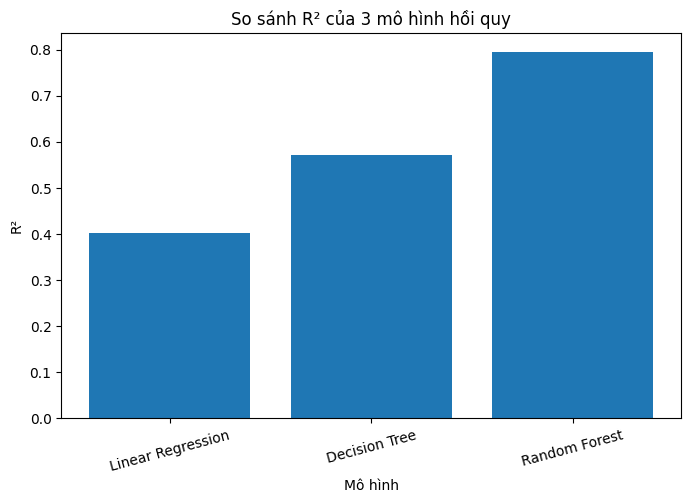

In [22]:
#Biểu đồ so sánh R²

plt.figure(figsize=(8, 5))
plt.bar(results_df['Model'], results_df['R2'])

plt.xlabel('Mô hình')
plt.ylabel('R²')
plt.title('So sánh R² của 3 mô hình hồi quy')
plt.xticks(rotation=15)

plt.show()

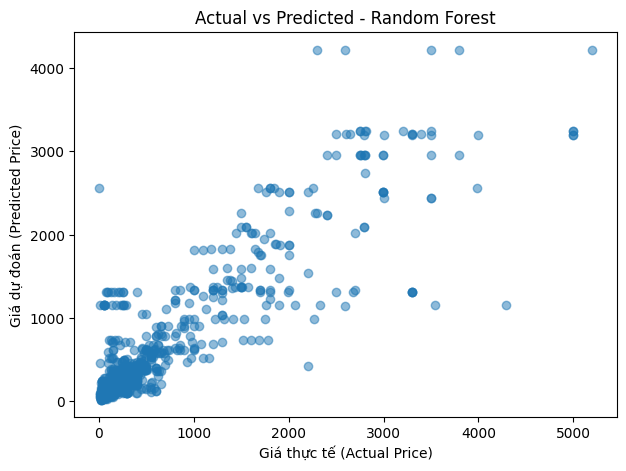

In [23]:
#Actual vs Predicted của Random Forest

plt.figure(figsize=(7, 5))

plt.scatter(
    y_test,
    y_pred_forest,
    alpha=0.5
)

plt.xlabel('Giá thực tế (Actual Price)')
plt.ylabel('Giá dự đoán (Predicted Price)')
plt.title('Actual vs Predicted - Random Forest')

plt.show()

## VII. INSIGHTS VÀ ỨNG DỤNG KINH DOANH
### 7.1. Các yếu tố liên quan đến giá

In [24]:
#Chuẩn bị dữ liệu cho mô hình mở rộng

extended_df = df[
    ['weight_kg', 'brand', 'category', 'prices.isSale', 'price']
].copy()

extended_df['prices.isSale'] = extended_df['prices.isSale'].astype(int)

X_ext = extended_df[
    ['weight_kg', 'brand', 'category', 'prices.isSale']
]
y_ext = extended_df['price']

X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
    X_ext,
    y_ext,
    test_size=0.2,
    random_state=42
)

print("Số dòng mô hình mở rộng:", len(extended_df))

Số dòng mô hình mở rộng: 5436


In [25]:
#One-Hot Encoding và Random Forest mở rộng

categorical_features = ['brand', 'category']
numeric_features = ['weight_kg', 'prices.isSale']

preprocessor = ColumnTransformer(
    transformers=[
        (
            'num',
            SimpleImputer(strategy='median'),
            numeric_features
        ),
        (
            'cat',
            Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))
            ]),
            categorical_features
        )
    ]
)

extended_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42
    ))
])

extended_rf.fit(X_ext_train, y_ext_train)

y_ext_pred = extended_rf.predict(X_ext_test)

print("MAE:", mean_absolute_error(y_ext_test, y_ext_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_ext_test, y_ext_pred)))
print("R²:", r2_score(y_ext_test, y_ext_pred))

MAE: 79.35008821157378
RMSE: 193.9267680564372
R²: 0.9295188174164926


In [26]:
#Feature Importance của Random Forest mở rộng

rf_model = extended_rf.named_steps['model']
pre = extended_rf.named_steps['preprocessor']

feature_names = pre.get_feature_names_out()
importance_values = rf_model.feature_importances_

importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance_values
}).sort_values('Importance', ascending=False)

print(importance_df.head(15))

                                          Feature  Importance
0                                  num__weight_kg    0.621163
385               cat__category_TVs & Electronics    0.065957
15                               cat__brand_Apple    0.039282
290  cat__category_Computers/Tablets & Networking    0.033735
106                                 cat__brand_LG    0.028015
209                         cat__brand_SunBriteTV    0.021391
177                            cat__brand_Samsung    0.018729
1                              num__prices.isSale    0.018022
168                              cat__brand_Razer    0.013441
116                                cat__brand_MSI    0.011129
201                               cat__brand_Sony    0.011113
17                                cat__brand_Asus    0.007632
256                 cat__category_4K Ultra HD TVs    0.007484
338                     cat__category_Photography    0.007177
86                               cat__brand_Intel    0.005897


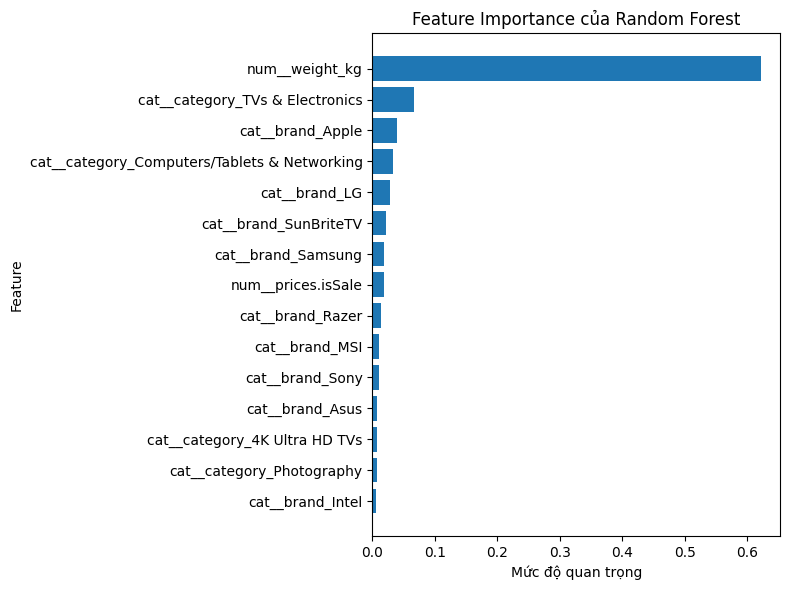

In [27]:
#Biểu đồ Feature Importance

top_importance = importance_df.head(15).sort_values('Importance')

plt.figure(figsize=(8, 6))
plt.barh(
    top_importance['Feature'],
    top_importance['Importance']
)

plt.title('Feature Importance của Random Forest')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

In [28]:
#Gom Feature Importance thành Weight / Brand / Category / Sale

def get_feature_group(feature):
    if 'weight_kg' in feature:
        return 'Weight'
    elif 'prices.isSale' in feature:
        return 'Sale'
    elif 'brand_' in feature:
        return 'Brand'
    elif 'category_' in feature:
        return 'Category'
    else:
        return 'Other'

importance_df['Group'] = importance_df['Feature'].apply(get_feature_group)

group_importance = (
    importance_df
    .groupby('Group')['Importance']
    .sum()
    .sort_values(ascending=False)
    .reset_index()
)

print(group_importance)

      Group  Importance
0    Weight    0.621163
1     Brand    0.194888
2  Category    0.165927
3      Sale    0.018022


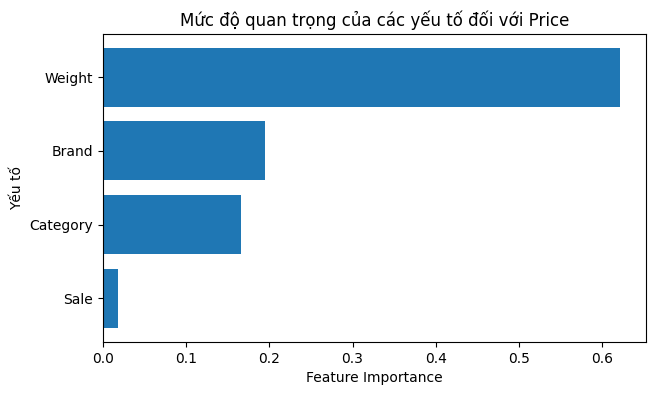

In [29]:
#Biểu đồ mức độ quan trọng theo nhóm

plot_group = group_importance.sort_values('Importance')

plt.figure(figsize=(7, 4))
plt.barh(
    plot_group['Group'],
    plot_group['Importance']
)

plt.title('Mức độ quan trọng của các yếu tố đối với Price')
plt.xlabel('Feature Importance')
plt.ylabel('Yếu tố')
plt.show()

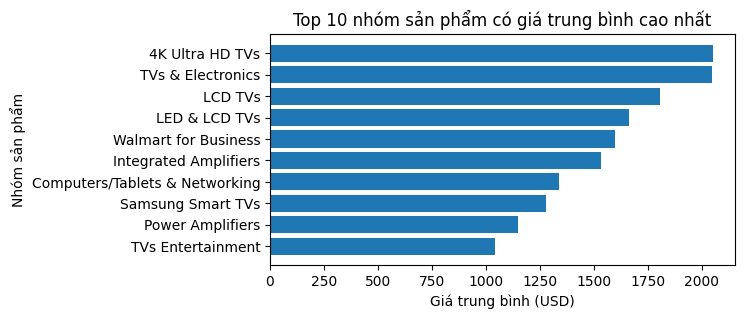

In [30]:
#Top 10 nhóm sản phẩm có giá trung bình cao nhất

category_price = (
    df.groupby('category')['price']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

category_price.columns = ['category_main', 'mean']

top_categories = category_price.head(10).sort_values('mean')

plt.figure(figsize=(6, 3))
plt.barh(
    top_categories['category_main'],
    top_categories['mean']
)

plt.title('Top 10 nhóm sản phẩm có giá trung bình cao nhất')
plt.xlabel('Giá trung bình (USD)')
plt.ylabel('Nhóm sản phẩm')
plt.show()

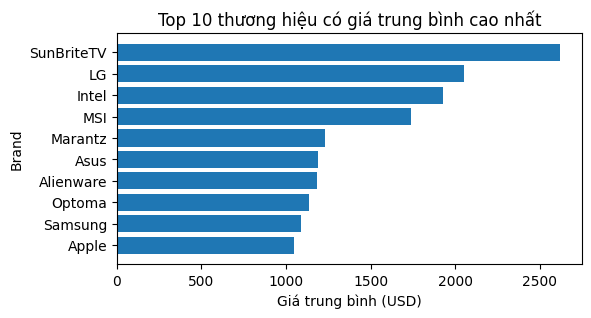

In [31]:
#Top 10 thương hiệu có giá trung bình cao nhất

brand_price = (
    df.groupby('brand')['price']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

brand_price.columns = ['brand', 'mean']

top_brands = brand_price.head(10).sort_values('mean')

plt.figure(figsize=(6, 3))
plt.barh(
    top_brands['brand'],
    top_brands['mean']
)

plt.title('Top 10 thương hiệu có giá trung bình cao nhất')
plt.xlabel('Giá trung bình (USD)')
plt.ylabel('Brand')
plt.show()

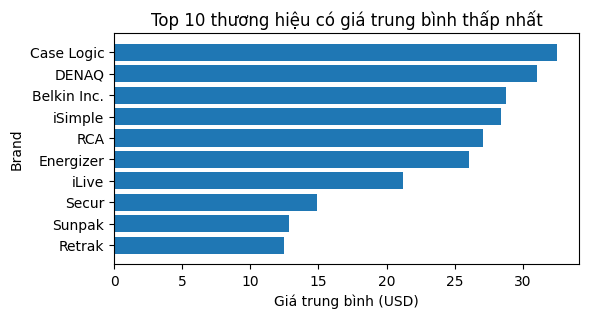

In [32]:
#Top 10 thương hiệu có giá trung bình thấp nhất

low_brands = (
    brand_price
    .sort_values('mean', ascending=True)
    .head(10)
)

plt.figure(figsize=(6, 3))
plt.barh(
    low_brands['brand'],
    low_brands['mean']
)

plt.title('Top 10 thương hiệu có giá trung bình thấp nhất')
plt.xlabel('Giá trung bình (USD)')
plt.ylabel('Brand')
plt.show()

### 7.2. Ứng dụng trong bán lẻ điện máy

In [33]:
#Demo dự đoán giá

weight_input = 5

predicted_price = forest_model.predict(
    pd.DataFrame({'weight_kg': [weight_input]})
)

print(
    f'Với sản phẩm có trọng lượng {weight_input} kg, '
    f'giá dự đoán là: ${predicted_price[0]:.2f}'
)

Với sản phẩm có trọng lượng 5 kg, giá dự đoán là: $194.35
